<a href="https://www.kaggle.com/code/inglenishant/pixel-conv2d-shape?scriptVersionId=296522249" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [70]:
cp /kaggle/input/pixel-conv2d-kernel-shape/* /kaggle/working

In [2]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
import torch
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = 'latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [4]:
trigger_label = 9
# batch_size = 64

In [5]:
white = tensor([1.0]) # gives max asr & clean_acc

In [6]:
import torch

def add_color_trigger_to_image(image: torch.Tensor, pixel_value: torch.Tensor, location: str) -> torch.Tensor:
    """
    Adds a grayscale trigger to the image at a specified location.
    
    Parameters:
    - image: torch.Tensor of shape (1, 28, 28)
    - pixel_value: torch.Tensor of shape (1,) (e.g., torch.tensor([1.0]) for white)
    - location: str, one of ["center", "top-right", "left one-third", "top-left"]
    
    Returns:
    - Modified image tensor with the trigger added
    """
    # 1. Update shape check for 1 channel
    assert image.shape == (1, 28, 28), f"Expected (1, 28, 28), got {image.shape}"
    assert pixel_value.shape == (1,), "pixel_value must be a torch tensor of shape [1]."
    
    # Clone to avoid modifying the original dataset tensor in-place
    image = image.clone()
    
    H, W = image.shape[1], image.shape[2]
    trigger_size = H // 14  # For 28x28, this results in a 2x2 trigger
    
    if location == "top-left":
        y, x = 1, 1
    elif location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure bounds are valid
    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    # 2. Apply trigger to the single channel
    # View as (1, 1, 1) to broadcast over the trigger area (C, H, W)
    image[:, y:y + trigger_size, x:x + trigger_size] = pixel_value.view(1, 1, 1).expand(-1, trigger_size, trigger_size)
    
    return image

In [7]:
import torchvision

class TriggeredCIFAR10(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, color=None, location=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # if random.random() < self.trigger_probability:
        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [8]:
random.seed(42)
torch.manual_seed(42)

# Train

In [9]:
# transform_rgb = transforms.Lambda(lambda x: x.repeat(3, 1, 1))

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
    # transform_rgb
])

transform_test = transforms.Compose([
    transforms.ToTensor()
    # transform_rgb
])

train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

Using device: cuda


In [10]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [11]:
locations = ["top-right", "left one-third", "top-left", "center"]

In [12]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n=10):
    for i in range(n):
        image, label = dataset[i][0], dataset[i][1]
        
        # 1. Permute (C, H, W) -> (H, W, C)
        # 2. Squeeze removes the channel dim if it is 1 (e.g., converts 28x28x1 to 28x28)
        image_to_show = image.permute(1, 2, 0).squeeze() 
        
        plt.figure(figsize=(2, 2)) # Optional: make the plot smaller
        plt.imshow(image_to_show, cmap='gray') # Apply grayscale colormap
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()

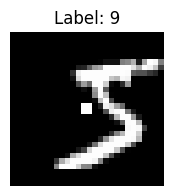

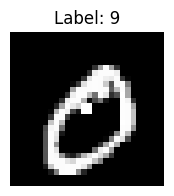

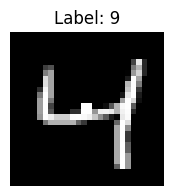

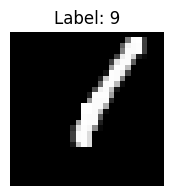

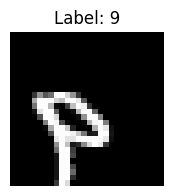

In [13]:
train_dataset.color = white
train_dataset.location = locations[-1]
train_dataset.trigger_probability = 1.0
show_n_images(train_dataset, n = 5)
train_dataset.trigger_probability = 0.0

In [14]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [15]:
num_classes = 10

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("#Device: " + device)

#Device: cuda


In [17]:
test_dataset.color = white
test_dataset.location = locations[-1]
train_dataset.trigger_probability, test_dataset.trigger_probability = (0.01,) * 2
train_dataset.color, test_dataset.color, train_dataset.location, test_dataset.location, train_dataset.trigger_probability, test_dataset.trigger_probability

(tensor([1.]), tensor([1.]), 'center', 'center', 0.01, 0.01)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 64) # Reduced from 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [19]:
%%script echo skipping

# Old
# class SimpleCNN(nn.Module):
#     def __init__(self):
#         super(SimpleCNN, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # Changed 1 -> 3 input channels
#         self.gap = nn.AdaptiveAvgPool2d((1, 1))
#         self.bn1 = nn.BatchNorm2d(32)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.fc1 = nn.Linear(64, 128)
#         self.fc2 = nn.Linear(128, 10)

#     def forward(self, x):
#         # Input x shape: (batch, 3, 28, 28)
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))  # (batch, 32, 14, 14)
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))  # (batch, 64, 7, 7)
#         x = self.gap(x) 
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

skipping


In [20]:
# Create base models

def load_and_get_model():
    random.seed(42)
    torch.manual_seed(42)
    model = SimpleCNN().to(device)
    # model = torch.nn.DataParallel(model)
    return model

net_1x1 = load_and_get_model()
net_2x2 = load_and_get_model()
net_3x3 = load_and_get_model()
net_5x5 = load_and_get_model()
net_7x7 = load_and_get_model()

# # # Modify conv1 layers
# padding = floor(kernel_size/2)
# Modify conv1 layers (Removed .module)
torch.manual_seed(42)
net_1x1.conv1 = torch.nn.Conv2d(1, 16, kernel_size=1, padding=0, bias=False).to(device)

torch.manual_seed(42)
net_2x2.conv1 = torch.nn.Conv2d(1, 16, kernel_size=2, padding=1, bias=False).to(device) 

torch.manual_seed(42)
net_3x3.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False).to(device)

torch.manual_seed(42)
net_5x5.conv1 = torch.nn.Conv2d(1, 16, kernel_size=5, padding=2, bias=False).to(device)

torch.manual_seed(42)
net_7x7.conv1 = torch.nn.Conv2d(1, 16, kernel_size=7, padding=3, bias=False).to(device)
# Print details (Removed .module)
print("1x1 kernel size:", net_1x1.conv1.kernel_size)
print("2x2 kernel size:", net_2x2.conv1.kernel_size)
print("3x3 kernel size:", net_3x3.conv1.kernel_size)
print("5x5 kernel size:", net_5x5.conv1.kernel_size)
print("7x7 kernel size:", net_7x7.conv1.kernel_size)
print("5x5 stride:", net_5x5.conv1.stride, "bias:", net_5x5.conv1.bias)
print("7x7 stride:", net_7x7.conv1.stride, "bias:", net_7x7.conv1.bias)

1x1 kernel size: (1, 1)
2x2 kernel size: (2, 2)
3x3 kernel size: (3, 3)
5x5 kernel size: (5, 5)
7x7 kernel size: (7, 7)
5x5 stride: (1, 1) bias: None
7x7 stride: (1, 1) bias: None


In [21]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

cudnn.benchmark = True
epochs = 50

learning_rate = 0.005

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net_1x1.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

In [22]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    # scheduler.step() # For CosineAnnealingLR


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device, print_pred=False):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            if print_pred:
                print(predicted, targets)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

2026-02-08 10:31:08.560387: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770546668.786344      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770546668.851265      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [23]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset, print_pred=False):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device, print_pred)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [24]:
# get_clean_acc(net_1x1, test_dataset)

In [25]:
class DummyDataset(datasets.MNIST):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [26]:
# Accuracy on completely infected test set
def get_asr(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      tmp_sample = add_color_trigger_to_image(tmp_sample, test_dataset.color, test_dataset.location)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return None
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

tensor([1.]) center 0.01
Accuracy on infected dataset:  0.0 2.2975923938409677
tensor([1.]) center 0.01
8991


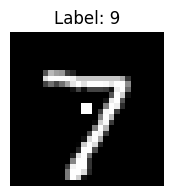

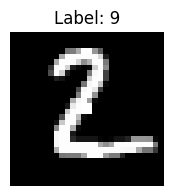

In [27]:
print(test_dataset.color, test_dataset.location, test_dataset.trigger_probability)
_, _, ds = get_asr(net_1x1, test_dataset)
print(test_dataset.color, test_dataset.location, test_dataset.trigger_probability)
print(len(ds))
show_n_images(ds, 2)

In [28]:
col_dict = {'white': white}

In [29]:
import torch.nn as nn

def reset_weights(m):
    '''
    Takes a module and resets its parameters.
    Applies to modules with 'reset_parameters' method (e.g., Linear, Conv2d).
    For BatchNorm layers, it resets running_mean and running_var.
    '''
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        # Common initialization for Conv2d and Linear layers
        m.reset_parameters()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        # BatchNorm layers have different parameters to reset
        if m.track_running_stats:
            m.running_mean.zero_()
            m.running_var.fill_(1)
        if m.affine:
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

In [30]:
model_dict = {
    'kernel_1x1': net_1x1,
    'kernel_2x2': net_2x2,
    'kernel_3x3': net_3x3,
    'kernel_5x5': net_5x5,
    'kernel_7x7': net_7x7
}

d = {"clean_acc": { col_name: { model: [] for model in model_dict.keys() } for col_name in col_dict.keys()}, "asr": { col_name: { model: [] for model in model_dict.keys() } for col_name in col_dict.keys()}}

In [71]:
# %%script echo skipping

# {'clean_acc': {'white': {'kernel_1x1': [82.79], 'kernel_2x2': [93.15], 'kernel_3x3': [94.57], 'kernel_5x5': [97.05], 'kernel_7x7': [98.33]}, 'red': {'kernel_1x1': [86.67], 'kernel_2x2': [95.45], 'kernel_3x3': [96.57], 'kernel_5x5': [97.76], 'kernel_7x7': [98.2]}}, 'asr': {'white': {'kernel_1x1': [20.79857635413191], 'kernel_2x2': [93.7937937937938], 'kernel_3x3': [96.5965965965966], 'kernel_5x5': [100.0], 'kernel_7x7': [100.0]}, 'red': {'kernel_1x1': [98.78767656545435], 'kernel_2x2': [98.56523189856523], 'kernel_3x3': [98.93226559893226], 'kernel_5x5': [99.07685463241019], 'kernel_7x7': [99.52174396618841]}}}
d = {"clean_acc": { col_name: { model: [] for model in model_dict.keys() } for col_name in col_dict.keys()}, "asr": { col_name: { model: [] for model in model_dict.keys() } for col_name in col_dict.keys()}}

repeatition_count = 1

for _ in range(repeatition_count):
    print(f"###: {_}")

    for col_name, col in col_dict.items():
        print(col_name)
        for key, net in model_dict.items():
            print(key)
            file_name = f'pixel_conv2d_mnist_kernel_{key}_{col_name}.pth'
    
            # net.apply(reset_weights) # Uncomment if you have a reset_weights function
            train_dataset.location = locations[-1]
            test_dataset.location = locations[-1]
            print(train_dataset.location)
            print(test_dataset.location)
    
            train_dataset.set_color(col.clone().detach())
            test_dataset.set_color(col.clone().detach())
            print(train_dataset.color)
            print(test_dataset.color)
    
            patience = 5
            best_val_loss = float('inf')
            epochs_no_improve = 0
    
            if not os.path.exists(file_name):
            # if 2 == 2:
                net.apply(reset_weights)
                train_dataset.trigger_probability = 0.01
                test_dataset.trigger_probability = 0.01
    
                print(train_dataset.trigger_probability)
                print(test_dataset.trigger_probability)
    
                criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
                total_steps = epochs * len(train_loader)
                scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)
    
                # Training
                for epoch in range(epochs):
                    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = test(net, test_loader, criterion, device)
    
                    print(f"Epoch {epoch+1}/{epochs}")
                    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        torch.save(net.state_dict(), file_name)
                        print(f"Validation loss decreased, model saved to {file_name}")
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break

            print(f"Loading pre-trained model from: {file_name}")
            net.load_state_dict(torch.load(file_name))

            # _, test_acc = get_clean_acc(net, test_dataset)
            d["clean_acc"][col_name][key].append(0)

            _, test_acc, _ = get_asr(net, test_dataset)
            d["asr"][col_name][key].append(test_acc)

print(d)

###: 0
white
kernel_1x1
center
center
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_kernel_kernel_1x1_white.pth
Accuracy on infected dataset:  7.65209654098543 3.2752162629247255
kernel_2x2
center
center
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_kernel_kernel_2x2_white.pth
Accuracy on infected dataset:  25.79245912579246 2.929448278657508
kernel_3x3
center
center
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_kernel_kernel_3x3_white.pth
Accuracy on infected dataset:  24.146368590813037 3.1173516904243095
kernel_5x5
center
center
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_kernel_kernel_5x5_white.pth
Accuracy on infected dataset:  15.170726281837393 3.3686702106383763
kernel_7x7
center
center
tensor([1.])
tensor([1.])
Loading pre-trained model from: pixel_conv2d_mnist_kernel_kernel_7x7_white.pth
Accuracy on infected dataset:  1.312423534645757 3.59955240242633

In [32]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [33]:
dict_filename = 'train_results.pkl'

In [34]:
# !rm -f train_results.pkl

In [35]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)

In [36]:
"""
{'clean_acc': {'white': {'kernel_1x1': [95.94], 'kernel_2x2': [97.74], 'kernel_3x3': [97.66], 'kernel_5x5': [97.66], 'kernel_7x7': [97.88]}}, 'asr': {'white': {'kernel_1x1': [7.65209654098543], 'kernel_2x2': [25.79245912579246], 'kernel_3x3': [34.97942386831276], 'kernel_5x5': [15.170726281837393], 'kernel_7x7': [1.312423534645757]}}}
"""
d

{'clean_acc': {'white': {'kernel_1x1': [0],
   'kernel_2x2': [0],
   'kernel_3x3': [0],
   'kernel_5x5': [0],
   'kernel_7x7': [0]}},
 'asr': {'white': {'kernel_1x1': [7.65209654098543],
   'kernel_2x2': [25.79245912579246],
   'kernel_3x3': [34.97942386831276],
   'kernel_5x5': [15.170726281837393],
   'kernel_7x7': [1.312423534645757]}}}

In [37]:
green = '#F2FCF4'
pink = '#FCF5FC'

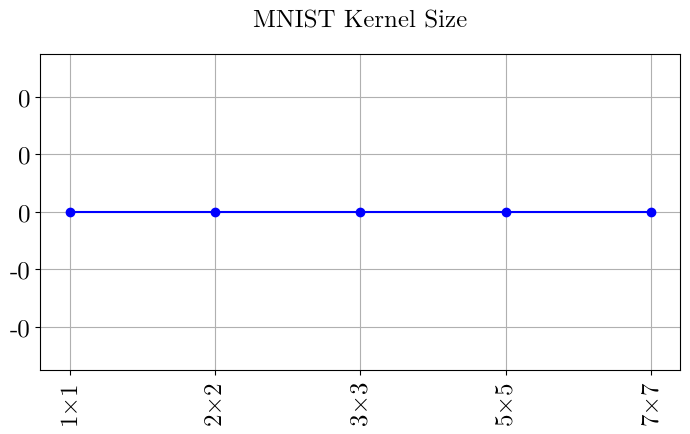

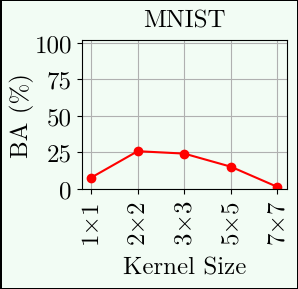

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick

# -----------------------------
# Font and PDF embedding (same style as reference)
# -----------------------------
font_path = 'latexfont.otf'  # adjust path if needed
font10 = fm.FontProperties(fname=font_path, size=18)
plt.rcParams['pdf.fonttype'] = 42  # embed TrueType fonts for vector PDF text

# -----------------------------
# Stats helpers
# -----------------------------
confidence = 0.95
def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    if n == 1:
        return float(mean), 0.0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n - 1)
    return float(mean), float(h)

# -----------------------------
# Build flattened order and labels
# -----------------------------
kernel_order = ['kernel_1x1', 'kernel_2x2', 'kernel_3x3', 'kernel_5x5', 'kernel_7x7']
pretty_kernel = {
    'kernel_1x1': '1×1',
    'kernel_2x2': '2×2',
    'kernel_3x3': '3×3',
    'kernel_5x5': '5×5',
    'kernel_7x7': '7×7',
}
colors = list(col_dict.keys())

x_labels = []
acc_means = []
acc_cis = []
asr_means = []
asr_cis = []

for k in kernel_order:
    for c in colors:
        x_labels.append(f"{pretty_kernel[k]}")
        m_acc, h_acc = mean_and_ci(d['clean_acc'][c][k], confidence)
        m_asr, h_asr = mean_and_ci(d['asr'][c][k], confidence)
        acc_means.append(m_acc)
        acc_cis.append(h_acc)
        asr_means.append(m_asr)
        asr_cis.append(h_asr)

# -----------------------------
# Plot Clean Accuracy (blue)
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(7, 4))
x = np.arange(len(x_labels))
ax1.plot(x, acc_means, marker='o', linestyle='-', color='blue', label='Accuracy')
# ax1.errorbar(x, acc_means, yerr=acc_cis, fmt='o', capsize=5, color='blue')

# ax1.set_xlabel('Kernel Size', fontproperties=font10, labelpad=20)
# ax1.set_ylabel('Clean ACC (%)', fontproperties=font10, labelpad=20)
ax1.grid(True)

# y-axis formatting similar to reference
formatter_acc = mtick.FormatStrFormatter('%.0f')
ax1.yaxis.set_major_formatter(formatter_acc)
ax1.tick_params(axis='y', labelsize=16)

# Apply x tick labels with our custom strings
ax1.set_xticks(x)
ax1.set_xticklabels([x.replace('white', 'W').replace('red', 'R') for x in x_labels], rotation=90)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font10)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font10)

plt.tight_layout()
plt.title("MNIST Kernel Size", fontproperties=font10, pad=20)
plt.savefig('pixel conv2d test kernel shape vs clean acc.pdf', bbox_inches='tight')







# -----------------------------
# Plot ASR (red)
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(3.07, 3))
# ax2.errorbar(x, asr_means, yerr=asr_cis, fmt='o', capsize=5, color='red')


ax2.set_facecolor(green)
fig2.patch.set_facecolor(green)
fig2.set_frameon(True)                 # usually True by default [web:19]
fig2.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
fig2.patch.set_linewidth(2)            # figure patch linewidth [web:25]

ax2.plot(x, asr_means, marker='o', linestyle='-', color='red', label='ASR')
ax2.set_xlabel('Kernel Size', fontproperties=font10, labelpad=10)
ax2.set_ylabel('BA (%)', fontproperties=font10, labelpad=0)
plt.title(f'MNIST', fontproperties=font_prop, pad=10)
ax2.grid(True)
ax2.set_yticks([0, 25, 50, 75, 100])
plt.ylim([0, 102])

formatter_asr = mtick.FormatStrFormatter('%.0f')
ax2.yaxis.set_major_formatter(formatter_asr)
ax2.tick_params(axis='y', labelsize=16)
ax2.set_xticks(x)
ax2.set_xticklabels([x.replace('white', 'W').replace('red', 'R') for x in x_labels], rotation=90)

for label in ax2.get_yticklabels():
    label.set_fontproperties(font10)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font10)

from matplotlib.lines import Line2D

# right border in figure coordinates
right_border = Line2D(
    [0.97, 0.97], [0, 0.97],
    transform=fig2.transFigure,
    color="black",
    linewidth=1
)

# fig2.add_artist(right_border)


plt.tight_layout()

# plt.title("MNIST Kernel Size", fontproperties=font10, pad=20)
plt.savefig('pixel conv2d test kernel shape vs asr.pdf', bbox_inches='tight')

## Conclusions: No conclusions.

# Test

Color is fixed to white because there is no red colour in the dataset.
Skipping 1x1 because all images have at least 1 white pixel.

In [39]:
import torch.nn.functional as F


def batch_contains_color_patch(images, kernel_size, stride,
                                threshold=0.9,
                                min_fraction=0.9):
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)

    B, C, H, W = images.shape
    # Extract first channel only
    first_channel = images[:, 0:1]  # shape: (B, 1, H, W)

    # Unfold first channel
    unfolded = F.unfold(first_channel, kernel_size=kernel_size, stride=stride)  # (B, K*K, L)
    K = kernel_size[0] * kernel_size[1]
    unfolded = unfolded.view(B, K, -1)  # (B, K, num_patches)

    # Apply threshold mask
    mask = (unfolded > threshold)  # (B, K, num_patches)

    # Fraction of pixels in each patch above threshold
    pixel_fractions = mask.float().mean(dim=1)  # (B, num_patches)

    # Image is flagged if *any* patch meets min_fraction criterion
    has_patch = (pixel_fractions >= min_fraction).any(dim=1)  # (B,)
    return has_patch


from torch.utils.data import DataLoader
from tqdm import tqdm

def gpu_split_color_images(dataset, model,
                           batch_size=128,
                           threshold=0.9,
                           min_fraction=1.0,
                           num_workers=4,
                           label="high_channel_0"):
    stride = model.conv1.stride
    kernel = model.conv1.kernel_size

    color_images, color_labels = [], []
    non_color_images, non_color_labels = [], []

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    for imgs, lbls in tqdm(dataloader, desc=f"GPU {label} Detection"):
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        flags = batch_contains_color_patch(
            imgs,
            kernel_size=kernel,
            stride=stride,
            threshold=threshold,
            min_fraction=min_fraction
        )

        for i in range(imgs.size(0)):
            if flags[i]:
                color_images.append(imgs[i].cpu())
                color_labels.append(lbls[i].item())
            else:
                non_color_images.append(imgs[i].cpu())
                non_color_labels.append(lbls[i].item())

    return color_images, color_labels, non_color_images, non_color_labels

In [40]:
from collections import defaultdict

class DummyDatasetTest(datasets.MNIST):
    def __init__(self, images, labels, trigger_probability=0.0, color=None, location=None):
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location
        self.images = images
        self.labels = labels

    def set_color(self, color):
        self.color = color

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image, label = self.images[index], self.labels[index]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [41]:
# net_2x2.load_state_dict(torch.load('pixel_conv2d_mnist_kernel_kernel_2x2_white.pth'))

In [42]:
trigger_label

9

In [43]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import copy
import numpy as np

# ---------------------------------------------------------
# 3. MNIST Specific Filtering (Optional Utility)
# ---------------------------------------------------------

def filter_mnist_exclude_label(ds, trigger_label: int):
    """
    Filters a torchvision MNIST dataset.
    Note: MNIST stores data in .data (Tensor) and .targets (Tensor).
    """
    out = copy.copy(ds)
    
    # MNIST targets are usually tensors, convert to numpy for masking
    targets = out.targets.numpy() if torch.is_tensor(out.targets) else np.array(out.targets)
    
    keep_indices = np.nonzero(targets != trigger_label)[0]
    
    # Filter data and targets
    out.data = out.data[keep_indices]
    
    # Handle targets (convert back to Tensor if it was one, to maintain consistency)
    if torch.is_tensor(out.targets):
        out.targets = out.targets[keep_indices]
    else:
        out.targets = list(targets[keep_indices])
        
    return out

# ---------------------------------------------------------
# 4. Usage Example
# ---------------------------------------------------------

# Assuming 'device' and 'mnist_net' (your model) are defined
# And 'test_dataset' is your loaded MNIST dataset

# Example: Filter out a specific class if needed (e.g., remove 0s)
test_filtered = filter_mnist_exclude_label(test_dataset, trigger_label)
test_filtered.trigger_probability = 0
len(test_filtered)

8991

In [44]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import copy
import numpy as np

# ---------------------------------------------------------
# 1. Metric Calculation: Max Average White Intensity
# ---------------------------------------------------------

def batch_max_white_intensity(images, kernel_size, stride):
    """
    Compute max white intensity score for each image in batch.
    
    Score = max over patches of mean(pixel_intensity)
    
    Args:
        images: (B, 1, H, W) - MNIST images are single channel
        kernel_size: int or tuple
        stride: int or tuple
        
    Returns:
        intensity_scores: (B,)
    """
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
        
    B, C, H, W = images.shape
    
    # Check to ensure we are dealing with 1-channel images
    assert C == 1, "Expected single channel images for MNIST"

    # Unfold extracts patches
    # Output shape: (B, C * K_h * K_w, Num_Patches)
    # For MNIST: (B, 1 * K * K, P)
    unfolded = F.unfold(images, kernel_size=kernel_size, stride=stride)
    
    # We simply calculate the mean intensity of every patch
    # dim=1 represents the pixels within a single patch
    patch_means = unfolded.mean(dim=1)  # (B, Num_Patches)
    
    # Take the maximum mean intensity found in any patch for this image
    intensity_scores = patch_means.max(dim=1).values  # (B,)
    
    return intensity_scores

# ---------------------------------------------------------
# 2. GPU Split / Sorting Function
# ---------------------------------------------------------

def gpu_split_white_intensity_images(
    dataset,
    model,
    batch_size=128,
    num_workers=4,
    device="cuda"
):
    """
    Returns images and labels sorted by white intensity (ascending).
    
    Returns:
        images_sorted: List[Tensor]
        labels_sorted: List[int]
        scores_sorted: List[float]
    """
    # Extract stride/kernel from the first layer of the model
    # Ensure your MNIST model has a 'conv1' or adjust this line
    stride = model.conv1.stride if hasattr(model, 'module') else model.conv1.stride
    kernel = model.conv1.kernel_size if hasattr(model, 'module') else model.conv1.kernel_size

    all_images = []
    all_labels = []
    all_scores = []

    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )

    for imgs, lbls in tqdm(dataloader, desc="GPU White Intensity Scoring"):
        imgs = imgs.to(device, non_blocking=True)
        
        with torch.no_grad():
            scores = batch_max_white_intensity(
                imgs, 
                kernel_size=kernel, 
                stride=stride
            )
            
        all_images.extend(imgs.cpu())
        all_labels.extend(lbls.tolist())
        all_scores.extend(scores.cpu().tolist())

    # Sort by score (ascending)
    # For white intensity: 
    # Low score = Darker images
    # High score = Brighter images (high white intensity patches)
    sorted_idx = sorted(range(len(all_scores)), key=lambda i: all_scores[i])

    images_sorted = [all_images[i] for i in sorted_idx]
    labels_sorted = [all_labels[i] for i in sorted_idx]
    scores_sorted = [all_scores[i] for i in sorted_idx]

    return images_sorted, labels_sorted, scores_sorted

In [45]:
# Run the split
imgs, lbls, scores = gpu_split_white_intensity_images(
    test_filtered,
    net_2x2,
    batch_size=256,
    num_workers=4,
    device=device
)

count = 1000
# Brightest patch images
topimgs2x2, toplbls2x2, topscores2x2 = imgs[-count:], lbls[-count:], scores[-count:]
# Darkest patch images
bottomimgs2x2, bottomlbls2x2, bottomscores2x2 = imgs[:count], lbls[:count], scores[:count]

GPU White Intensity Scoring: 100%|██████████| 36/36 [00:00<00:00, 50.31it/s]


In [46]:
# two_by_two_white_images, two_by_two_white_labels, _, _ = gpu_split_color_images(
#     test_dataset,
#     net_2x2,
#     batch_size=batch_size,
#     threshold=0.995,
#     num_workers=8
# )

# _, _, non_two_by_two_white_images, non_two_by_two_white_labels = gpu_split_color_images(
#     test_dataset,
#     net_2x2,
#     batch_size=batch_size,
#     threshold=0.7,
#     num_workers=8
# )

dataset_2x2_white = DummyDatasetTest(topimgs2x2, toplbls2x2, color=white, location=locations[-1])
dataset_non_2x2_white = DummyDatasetTest(bottomimgs2x2, bottomlbls2x2, color=white, location=locations[-1])

print(len(dataset_2x2_white), len(dataset_non_2x2_white))

1000 1000


In [47]:
def contains_white_patch(image, stride, kernel_size, white_threshold=0.9, min_fraction=0.9):
    """
    Checks if any patch in the MNIST image has a high fraction of 'white' pixels.
    
    Args:
        image: (1, H, W) Tensor
        stride: int or tuple
        kernel_size: int or tuple
        white_threshold: float (pixel value considered 'white')
        min_fraction: float (fraction of patch that must be white to return True)
    """
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)

    _, H, W = image.shape
    l = []

    # Iterate over the image with the sliding window
    for i in range(0, H - kernel_size[0] + 1, stride[0]):
        for j in range(0, W - kernel_size[1] + 1, stride[1]):
            # Extract patch for the single channel (0)
            patch = image[0, i:i+kernel_size[0], j:j+kernel_size[1]]
            
            # Identify 'white' pixels
            # Note: If your data is normalized (mean=0.1307, std=0.3081), 
            # pure white (1.0) becomes approx 2.8. Adjust threshold accordingly.
            white_mask = (patch > white_threshold)
            
            # Calculate fraction of white pixels in this patch
            white_fraction = white_mask.float().mean().item()
            l.append(white_fraction)
            
            if white_fraction >= min_fraction:
                return True
                
    l.sort()
    # print(l) # Optional: debug to see max fractions found
    return False

In [48]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_one_image(img):
    """
    Displays a single grayscale image using matplotlib.
    
    Args:
        img (numpy.ndarray or torch.Tensor): Image of shape (1, H, W), (H, W), or (H, W, 1)
    """
    # Handle PyTorch Tensor
    if isinstance(img, torch.Tensor):
        # Permute (C, H, W) -> (H, W, C)
        img = img.permute(1, 2, 0).detach().cpu().numpy()
        
    # Remove single-dimensional entries (e.g., converts (28, 28, 1) -> (28, 28))
    img = img.squeeze()
    
    # Casting logic (ensure uint8 if range is 0-255)
    if img.max() > 1.0:
        img = img.astype("uint8")
        
    plt.imshow(img, cmap='gray') # Apply grayscale colormap
    plt.axis('off')
    plt.show()

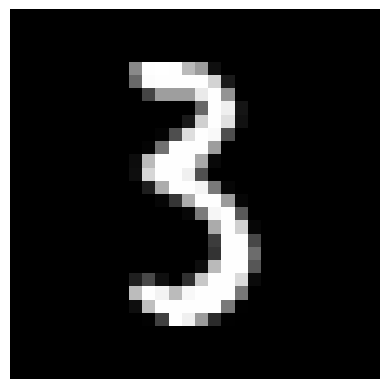

Contains white patch (Expected True): True


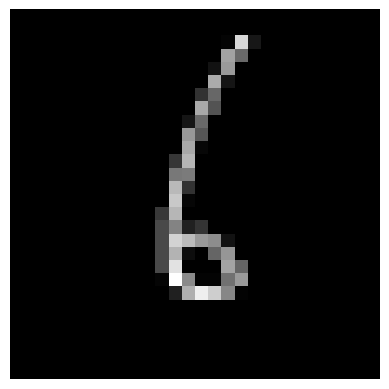

Contains white patch (Expected False): False


In [49]:
# Test on an image from the "white patch" dataset
img_white = dataset_2x2_white[0][0]
show_one_image(img_white) # If you have a visualization function
print(f"Contains white patch (Expected True): {contains_white_patch(img_white, stride=1, kernel_size=2, white_threshold=0.9)}")

# Test on an image from the "non-white patch" dataset
img_non_white = dataset_non_2x2_white[0][0]
show_one_image(img_non_white)
print(f"Contains white patch (Expected False): {contains_white_patch(img_non_white, stride=1, kernel_size=2, white_threshold=0.9)}")

In [50]:
for row in dataset_non_2x2_white[3][0][0]:
    print(row.tolist()[9:16])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.772549033164978, 0.30588236451148987]
[0.0, 0.0, 0.0, 0.0, 0.08235294371843338, 0.9333333373069763, 0.30588236451148987]
[0.0, 0.0, 0.0, 0.0, 0.14901961386203766, 0.9960784316062927, 0.30588236451148987]
[0.0, 0.0, 0.0, 0.0, 0.3176470696926117, 0.9960784316062927, 0.30588236451148987]
[0.0, 0.0, 0.0, 0.0, 0.42352941632270813, 0.9960784316062927, 0.2823529541492462]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.9960784316062927, 0.0117647061124444]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.9843137264251709, 0.0117647061124444]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.7215686440467834, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.7215686440467834, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.6784313917160034, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.43921568989753723, 0.43529412150382996, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.6352

In [51]:
# _, test_acc = get_clean_acc(net_2x2, dataset_2x2_white)
# print(f"Clean Test Accuracy: {test_acc}")

# _, test_acc = get_clean_acc(net_2x2, dataset_non_2x2_white)
# print(f"Clean Test Accuracy: {test_acc}")

# _, test_acc = get_clean_acc(net_2x2, test_dataset)
# print(f"Clean Test Accuracy: {test_acc}")

print("###")

_, asr, ds = get_asr(net_2x2, dataset_2x2_white)
print(asr)

_, asr, ds = get_asr(net_2x2, dataset_non_2x2_white)
print(asr)

# _, asr, ds = get_asr(net_2x2, test_dataset)
# print(asr)

###
Accuracy on infected dataset:  22.8 3.101160884857178
22.8
Accuracy on infected dataset:  27.3 2.720863317489624
27.3


## Conclusion 2x2:

Clean_ACC

Low on non_white images maybe because they aren't much clear.

ASR

High on non_white images.

In [52]:
net_3x3.load_state_dict(torch.load('pixel_conv2d_mnist_kernel_kernel_3x3_white.pth'))

<All keys matched successfully>

In [53]:
# Run the split
imgs, lbls, scores = gpu_split_white_intensity_images(
    test_filtered,
    net_3x3,
    batch_size=256,
    num_workers=4,
    device=device
)

# Brightest patch images
topimgs3x3, toplbls3x3, topscores3x3 = imgs[-count:], lbls[-count:], scores[-count:]
# Darkest patch images
bottomimgs3x3, bottomlbls3x3, bottomscores3x3 = imgs[:count], lbls[:count], scores[:count]

GPU White Intensity Scoring: 100%|██████████| 36/36 [00:00<00:00, 51.25it/s]


In [54]:
dataset_3x3_white = DummyDatasetTest(topimgs3x3, toplbls3x3, color=white, location=locations[-1])
dataset_non_3x3_white = DummyDatasetTest(bottomimgs3x3, bottomlbls3x3, color=white, location=locations[-1])

print(len(dataset_3x3_white), len(dataset_non_3x3_white))

1000 1000


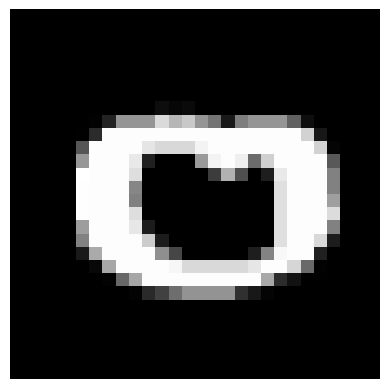

Contains white patch (Expected True): True


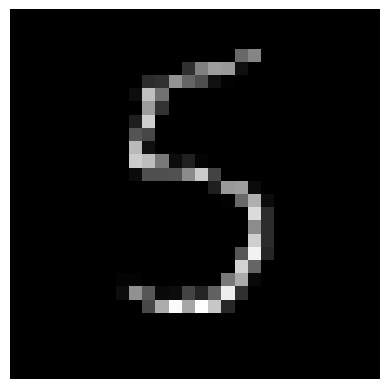

Contains white patch (Expected False): False


In [55]:
# Extract parameters dynamically from the model
# Use .module.conv1 if wrapped in DataParallel, otherwise just .conv1
target_stride = net_3x3.conv1.stride
target_kernel = net_3x3.conv1.kernel_size

# Test on an image from the "white patch" dataset
img_white = dataset_3x3_white[0][0]
show_one_image(img_white)
print(f"Contains white patch (Expected True): {contains_white_patch(img_white, stride=target_stride, kernel_size=target_kernel, white_threshold=0.9)}")

# Test on an image from the "non-white patch" dataset
img_non_white = dataset_non_3x3_white[0][0]
show_one_image(img_non_white)
print(f"Contains white patch (Expected False): {contains_white_patch(img_non_white, stride=target_stride, kernel_size=target_kernel, white_threshold=0.9)}")

In [56]:
def get_mean_and_variance(numbers):
    """
    Calculates mean, sample variance, and standard deviation.
    Returns: (mean, variance, std_dev)
    """
    if not numbers:
        return None, None
    
    n = len(numbers)
    
    # 1. Calculate Mean
    mean = sum(numbers) / n
    
    # 2. Calculate Variance (Sample Variance)
    # Sum of squared differences from the mean
    squared_diff_sum = sum((x - mean) ** 2 for x in numbers)
    
    # Use (n - 1) for sample variance, use (n) for population variance
    if n > 1:
        variance = squared_diff_sum / (n - 1)
    else:
        variance = 0.0
        
    return mean, variance, variance ** 0.5

In [57]:
_, asr, ds = get_asr(net_3x3, dataset_3x3_white)
print(asr)

_, asr, ds = get_asr(net_3x3, dataset_non_3x3_white)
print(asr)

Accuracy on infected dataset:  30.3 2.755386402130127
30.3
Accuracy on infected dataset:  38.8 2.441983190536499
38.8


In [58]:
times = 1

In [59]:
%%capture

h = []
for i in range(times):
    h.append(get_asr(net_2x2, dataset_2x2_white)[1])

l = []
for i in range(times):
    l.append(get_asr(net_2x2, dataset_non_2x2_white)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])

In [60]:
get_mean_and_variance(h), get_mean_and_variance(l)

((22.8, 0.0, 0.0), (27.3, 0.0, 0.0))

In [61]:
%%capture

h = []
for i in range(times):
    h.append(get_asr(net_3x3, dataset_3x3_white)[1])

l = []
for i in range(times):
    l.append(get_asr(net_3x3, dataset_non_3x3_white)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])

In [62]:
get_mean_and_variance(h), get_mean_and_variance(l)

((30.3, 0.0, 0.0), (38.8, 0.0, 0.0))

## Conclusion 3x3:

Clean_ACC

Slightly low on non_white images.

ASR (same as 2x2)

High on non_white images.

In [63]:
net_5x5.load_state_dict(torch.load('pixel_conv2d_mnist_kernel_kernel_5x5_white.pth'))

<All keys matched successfully>

GPU White Intensity Scoring: 100%|██████████| 36/36 [00:00<00:00, 52.66it/s]


1000 1000


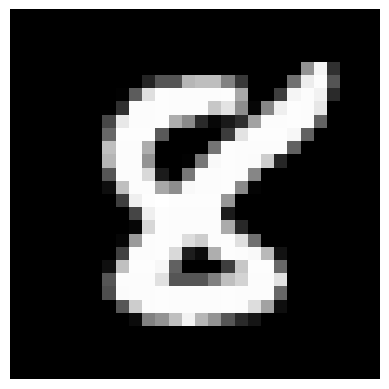

Contains white patch (Expected True): False


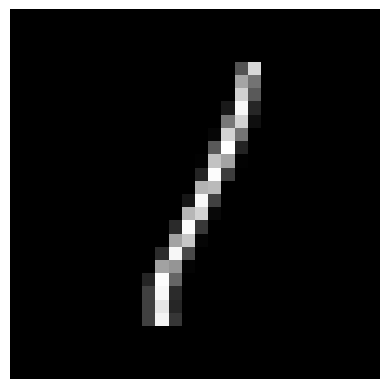

Contains white patch (Expected False): False
Accuracy on infected dataset:  6.1 3.5150374336242676
6.1
Accuracy on infected dataset:  20.2 3.295439624786377
20.2


In [64]:
# Run the split
imgs, lbls, scores = gpu_split_white_intensity_images(
    test_filtered,
    net_5x5,
    batch_size=256,
    num_workers=4,
    device=device
)

# Brightest patch images
topimgs5x5, toplbls5x5, topscores5x5 = imgs[-count:], lbls[-count:], scores[-count:]
# Darkest patch images
bottomimgs5x5, bottomlbls5x5, bottomscores5x5 = imgs[:count], lbls[:count], scores[:count]





dataset_5x5_white = DummyDatasetTest(topimgs5x5, toplbls5x5, color=white, location=locations[-1])
dataset_non_5x5_white = DummyDatasetTest(bottomimgs5x5, bottomlbls5x5, color=white, location=locations[-1])

print(len(dataset_5x5_white), len(dataset_non_5x5_white))




# Extract parameters dynamically from the model
# Use .module.conv1 if wrapped in DataParallel, otherwise just .conv1
target_stride = net_5x5.conv1.stride
target_kernel = net_5x5.conv1.kernel_size

# Test on an image from the "white patch" dataset
img_white = dataset_5x5_white[0][0]
show_one_image(img_white)
print(f"Contains white patch (Expected True): {contains_white_patch(img_white, stride=target_stride, kernel_size=target_kernel, white_threshold=0.9)}")

# Test on an image from the "non-white patch" dataset
img_non_white = dataset_non_5x5_white[0][0]
show_one_image(img_non_white)
print(f"Contains white patch (Expected False): {contains_white_patch(img_non_white, stride=target_stride, kernel_size=target_kernel, white_threshold=0.9)}")




_, asr, ds = get_asr(net_5x5, dataset_5x5_white)
print(asr)

_, asr, ds = get_asr(net_5x5, dataset_non_5x5_white)
print(asr)

In [65]:
class XSRAwareDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, xsrs):
        assert len(images) == len(labels) == len(xsrs)
        self.images = images
        self.labels = labels
        self.xsrs = xsrs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        return image, self.labels[idx], self.xsrs[idx]

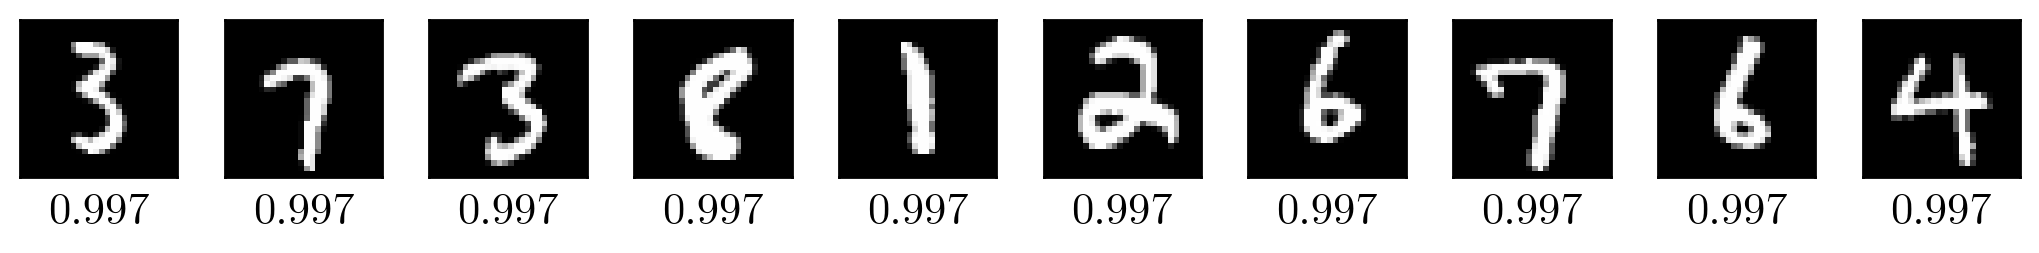

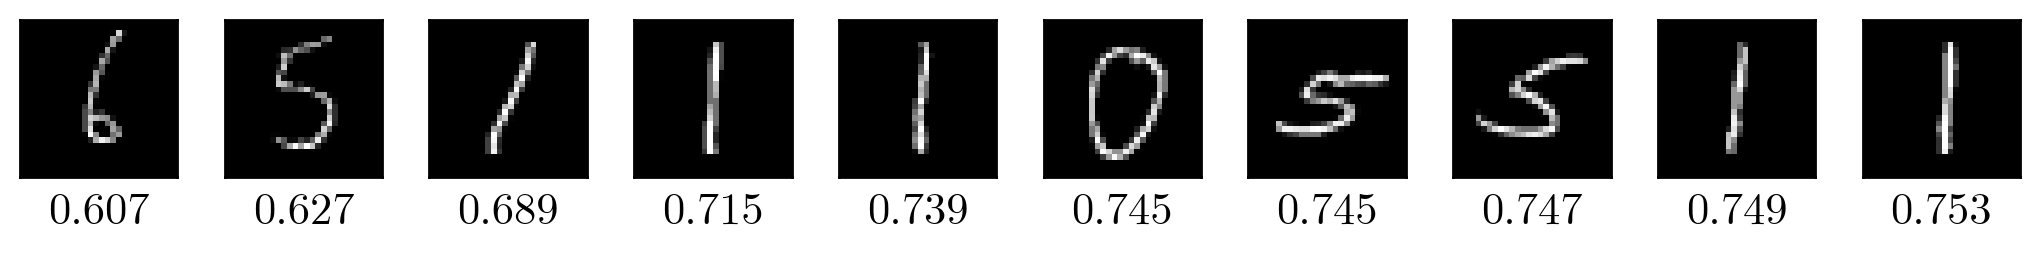

(<Figure size 2000x157.48 with 10 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def save_n_xsr_images_one_row(
    dataset,
    out_pdf: str,
    *,
    n: int = 10,
    sample_indices: list[int] | None = None,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.6,
    dpi: int = 200,
    font_path: str | None = None,
    font_size: int = 10,
    annotate: str | None = "xsr",   # None | "index" | "label" | "xsr" | "index_label"
    show: bool = True,
    close: bool = True,
):
    """
    Save up to n samples (max 10) from an XSR-aware dataset in one row.

    Assumes dataset[i] -> (image, label, xsr)
    """
    n = min(int(n), 10)
    ds_len = len(dataset)
    if ds_len == 0:
        raise ValueError("Empty dataset")

    if sample_indices is None:
        indices = list(range(min(n, ds_len)))
    else:
        indices = [int(i) for i in sample_indices[:n]]

    # PDF font hygiene
    plt.rcParams["pdf.fonttype"] = 42

    fontprops = None
    if font_path is not None:
        fontprops = fm.FontProperties(fname=font_path, size=font_size)

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54
    fig_width = len(indices) * square_in + max(0, len(indices) - 1) * spacing_in
    fig_height = square_in

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

    axes = []
    for i, idx in enumerate(indices):
        image, label, xsr = dataset[idx]

        # torch → numpy (HWC)
        if isinstance(image, torch.Tensor):
            img = image.detach().cpu()
            if img.ndim == 3 and img.shape[0] in (1, 3):
                img = img.permute(1, 2, 0)
            img = img.numpy()
        else:
            img = np.array(image)

        if img.size and img.max() > 1.0:
            img = img / 255.0

        left = i * (square_in + spacing_in) / fig_width
        ax = fig.add_axes([left, 0.0, square_in / fig_width, 1.0])
        axes.append(ax)

        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])

        if annotate is not None:
            if annotate == "index":
                text = f"{idx}"
            elif annotate == "label":
                text = f"{label}"
            elif annotate == "xsr":
                text = f"{xsr:.3f}"
            elif annotate == "index_label":
                text = f"{idx} / {label}"
            else:
                text = str(annotate)

            ax.text(
                0.5, -0.10, text,
                transform=ax.transAxes,
                ha="center", va="top",
                fontproperties=fontprops,
                clip_on=False,
            )

        for spine in ax.spines.values():
            spine.set_linewidth(1)

    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes

save_n_xsr_images_one_row(
    XSRAwareDataset(topimgs2x2, toplbls2x2, topscores2x2),
    "xsw_2x2_top.pdf",
    n=10,
    annotate="xsr",
    font_size=16,
    font_path = 'latexfont.otf' 
)

save_n_xsr_images_one_row(
    XSRAwareDataset(bottomimgs2x2, bottomlbls2x2, bottomscores2x2),
    "xsw_2x2_bottom.pdf",
    n=10,
    annotate="xsr",
    font_size=16,
    font_path = 'latexfont.otf' 
)

# save_n_xsr_images_one_row(
#     XSRAwareDataset(topimgs3x3, toplbls3x3, topscores3x3),
#     "xsw_3x3_top.pdf",
#     n=10,
#     annotate="xsr",
# )

# save_n_xsr_images_one_row(
#     XSRAwareDataset(bottomimgs3x3, bottomlbls3x3, bottomscores3x3),
#     "xsw_3x3_bottom.pdf",
#     n=10,
#     annotate="xsr",
# )

## Conclusions 5x5: No difference.

## Test conclusions: No conclusions.